In [53]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [54]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [55]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")
os.listdir(path)

# Read data
df = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))

## EDA


In [56]:
# Print information
print("Shape:", df.shape)
print(df.dtypes)

display(df.head())

Shape: (60000, 785)
label       int64
pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 785, dtype: object


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Visualización de imágenes

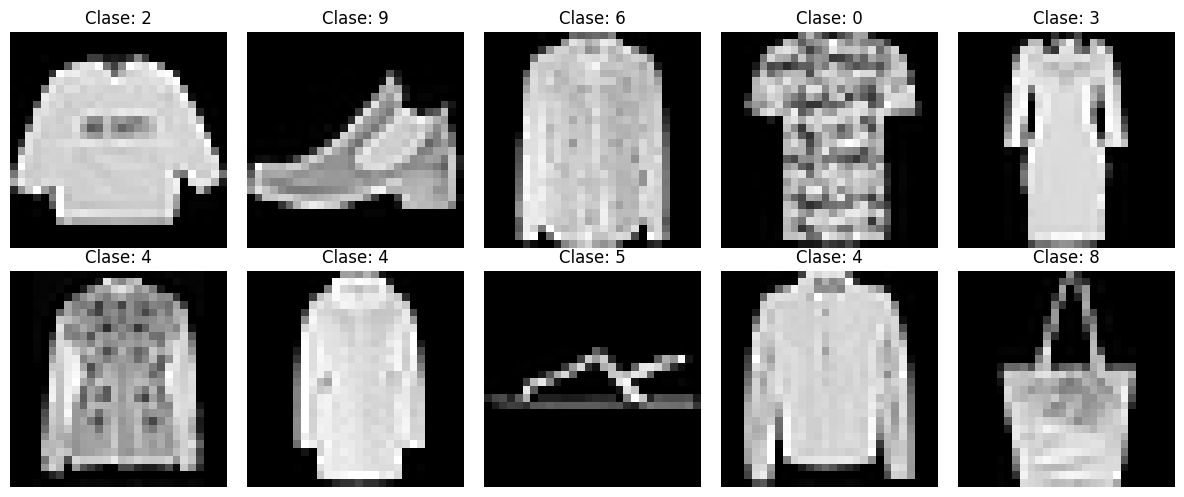

In [57]:
# Plot first 10 images

X_train = df.drop("label", axis=1)
X = X_train.values

y = df["label"].values

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Clase: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


### Distribución de clases

La distribución de las clases es equilibrada, ya que cada una de las 10 categorías contiene 6000 imágenes. Esto significa que no existe un desbalance entre las clases del conjunto de datos, por lo que todas las categorías tienen la misma representación y no es necesario aplicar técnicas de balanceo de clases.


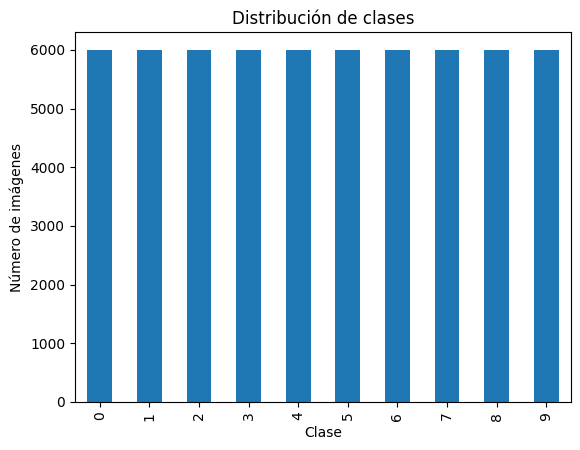

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000


In [59]:
# Distribución de clases

df["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases")
plt.show()

print(df["label"].value_counts().sort_index().to_string())

### Missing values

No se encontraron valores nulos en el conjunto de datos. Esto indica que todas las imágenes cuentan con información en sus atributos de píxeles y que no es necesario realizar un proceso de imputación de valores faltantes.


In [60]:

print("Missing values:", df.isnull().sum().sum())


Missing values: 0


### Registros duplicados

Se encontraron 43 registros duplicados, equivalentes aproximadamente al 0,072 % del conjunto de entrenamiento. Debido a su baja proporción, se reportan como parte del análisis de calidad de los datos sin eliminarlos automáticamente.



In [74]:
duplicados = df.duplicated().sum()
total = len(df)

print("Duplicados:", duplicados)
print("Porcentaje:", (duplicados / total) * 100)

Duplicados: 43
Porcentaje: 0.07166666666666667


### Estadísticas de los píxeles

La intensidad de los píxeles se encuentran entre 0 y 255, donde 0 representa ausencia de intensidad y 255 corresponde a la máxima intensidad. La media de 72.96 indica que, en promedio, los píxeles presentan una intensidad relativamente baja. Esto es coherente el dataset de Fashion-MNIST, ya que las prendas suelen estar representadas sobre un fondo oscuro. La desviación estándar de 89.97 muestra una dispersión considerable en los valores de intensidad, lo que indica que existe una diferencia importante entre las zonas oscuras y las zonas que contienen información visual de las prendas. No se identifican valores fuera del rango esperado, dado que el mínimo es 0 y el máximo 255.


In [61]:
print("Mean: ", X.mean())
print("Std: ", X.std())
print("Min: ", X.min())
print("Max: ", X.max())


Mean:  72.9568306122449
Std:  89.9668629851211
Min:  0
Max:  255


### Distribución de intensidades

La distribución de intensidades muestra valores entre 0 y 255, correspondientes a una imagen en escala de grises. Se observa una alta frecuencia de píxeles con intensidad 0, lo que indica una importante presencia de zonas oscuras o de fondo en las imágenes. También se presentan valores elevados de intensidad, correspondientes principalmente a las zonas donde se encuentran las prendas. Esta distribución confirma la variabilidad de intensidad presente en las imágenes y permite identificar la necesidad de normalizar los valores durante el preprocesamiento.


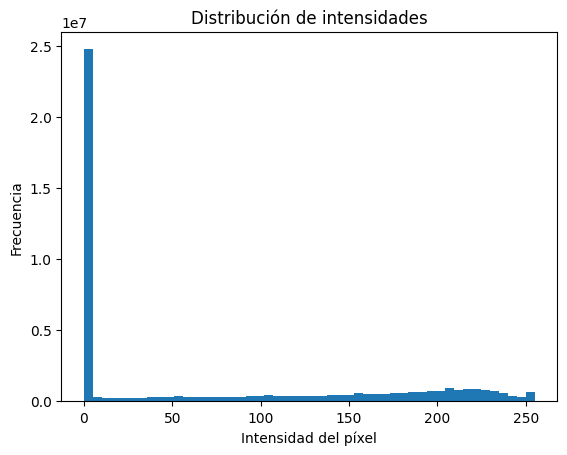

In [62]:
plt.hist(X.flatten(), bins=50)
plt.xlabel("Intensidad del píxel")
plt.ylabel("Frecuencia")
plt.title("Distribución de intensidades")
plt.show()


## Preprocesamiento y reducción


### Normalización

Las imágenes se normalizan dividiendo los valores de intensidad de los píxeles entre 255, transformando el rango original de 0–255 al rango [0, 1]. Esto facilita el procesamiento numérico y proporciona una representación más adecuada para aplicar técnicas de aprendizaje automático como PCA.


In [63]:
X = X / 255.0

In [64]:
# Contar valores nulos en el dataset de nuevo
print(df.isnull().sum().sum())

0


### Aplicación PCA

Utilizamos PCA con 2 componentes para la visualización, permitiendo observar la distribución y posible separación de las clases en un plano.


In [65]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X)

print(X_pca_2.shape)

(60000, 2)


In [66]:
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=5)

# plt.xlabel("Componente principal 1")
# plt.ylabel("Componente principal 2")
# plt.title("Fashion-MNIST después de PCA")
# plt.show()

#### PCA en 2 componentes

Las clases `Shirt`, `T-shirt/top`, `Pullover` y `Coat` presentan un mayor solapamiento en la representación de las dos primeras componentes principales, lo que indica que sus características visuales son similares y no se separan claramente en este espacio reducido. Por otro lado, `Sneaker` y `Trouser` presentan agrupamientos más definidos y una mayor separación respecto a otras clases.

Esto evidencia que las dos primeras componentes principales permiten visualizar parte de la estructura del conjunto de datos, aunque representan solamente una fracción de la información contenida en las 784 características originales.



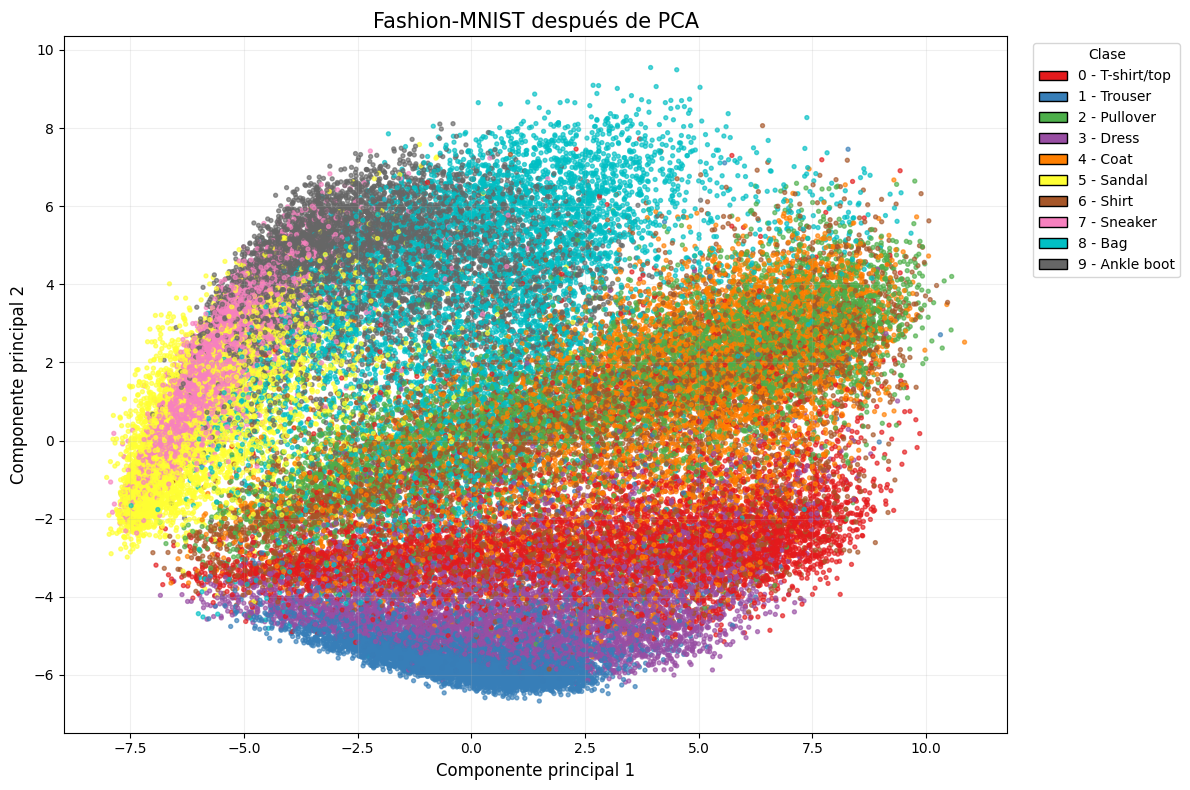

In [67]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Nombres de las clases
class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

# Colores claramente diferenciados para las 10 clases
colors = [
    "#e41a1c",  # 0 - Rojo
    "#377eb8",  # 1 - Azul
    "#4daf4a",  # 2 - Verde
    "#984ea3",  # 3 - Morado
    "#ff7f00",  # 4 - Naranja
    "#ffff33",  # 5 - Amarillo
    "#a65628",  # 6 - Café
    "#f781bf",  # 7 - Rosado
    "#00bfc4",  # 8 - Turquesa
    "#666666",  # 9 - Gris
]

cmap = ListedColormap(colors)

# Gráfico PCA
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap=cmap, vmin=0, vmax=9, s=8, alpha=0.65
)

plt.xlabel("Componente principal 1", fontsize=12)
plt.ylabel("Componente principal 2", fontsize=12)
plt.title("Fashion-MNIST después de PCA", fontsize=15)

# Crear leyenda auxiliar
legend_elements = [
    Patch(facecolor=colors[i], edgecolor="black", label=f"{i} - {class_names[i]}")
    for i in range(10)
]

plt.legend(
    handles=legend_elements, title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [68]:
print("Varianza explicada por PC1:", pca_2.explained_variance_ratio_[0])
print("Varianza explicada por PC2:", pca_2.explained_variance_ratio_[1])
print("Varianza explicada acumulada:", pca_2.explained_variance_ratio_.sum())

Varianza explicada por PC1: 0.2901135344536355
Varianza explicada por PC2: 0.1772766836614786
Varianza explicada acumulada: 0.46739021811511416


#### Varianza explicada por PCA

Mediante PCA se redujo la dimensionalidad de las imágenes de 784 características originales a 187 componentes principales, conservando aproximadamente el 95 % de la varianza. Esto permite reducir considerablemente la cantidad de características y mantener la mayor parte de la variabilidad presente en los datos.


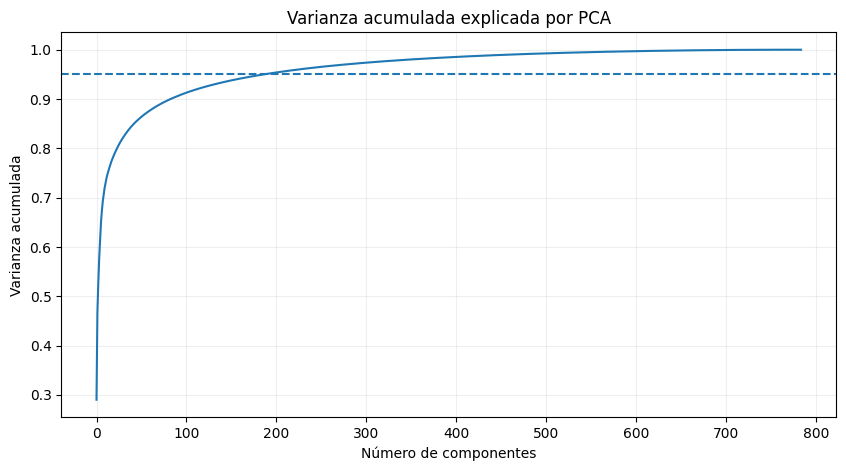

In [69]:
pca = PCA()
pca.fit(X)

varianza_acumulada = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(varianza_acumulada)
plt.axhline(y=0.95, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada explicada por PCA")
plt.grid(alpha=0.2)
plt.show()

In [70]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X)

print("Numero de componentes:", X_pca_95.shape[1])

Numero de componentes: 187
